
# Working with XES Event Logs in Python

**This notebook is part of the Process Intelligence in Action (2AMI30) course**

This notebook is a hands-on introduction to the **XES (.xes) event log format**, which is widely used in **process mining**.  
You are expected to be comfortable with Python, pandas, and Jupyter notebooks.

This notebook will cover:
- Understanding the structure of an XES file (log → trace → event)
- Loading and inspecting XES files in Python
- Converting XES logs to pandas DataFrames
- Performing basic exploratory analysis on event logs

We will use the `pm4py` library, the de‑facto standard for process mining in Python.



## 1. Understanding the structure of an XES file

The **eXtensible Event Stream (XES)** format is an XML-based standard for event logs.

Conceptually, an XES log has three nested levels:

1. **Log** – the whole dataset
2. **Trace** – one process instance
3. **Event** – one step in the process

Each level can have **attributes**:
- Events typically have: `concept:name`, `time:timestamp`, `org:resource`
- Traces often have: `case_id`, `customer`, `variant`

Think of a trace as a sequence of time-ordered events describing *what happened* for a single case.



## 2. Required libraries

We use **pm4py** for reading and analyzing XES logs.

If pm4py is not installed, run the following (once):
```bash
pip install pm4py
```


In [1]:

import pm4py
import pandas as pd

from pm4py.objects.log.importer.xes import importer as xes_importer
from pm4py.objects.conversion.log import converter as log_converter



## 3. Loading an XES file

Place your `.xes` file in the same directory as this notebook, or update the path below.


In [2]:

# Update this path to your XES file
xes_path = "D:\\TUE Study Material\\Q4\\Process Intelligence in Action\\Assignment\\Process-Analytics-in-Action\\Supermarket_Manager.xes"

log = xes_importer.apply(xes_path)

print(type(log))
print(f"Number of traces: {len(log)}")


d:\TUE Study Material\Q2\Advanced Process Mining\Assignment\Phase3\course-applied-processmining\.venv\lib\site-packages\pm4py\util\dt_parsing\parser.py:82: UserWarning: ISO8601 strings are not fully supported with strpfromiso for Python versions below 3.11
  warnings.warn(


parsing log, completed traces ::   0%|          | 0/2 [00:00<?, ?it/s]

<class 'pm4py.objects.log.obj.EventLog'>
Number of traces: 2



## 4. Inspecting traces and events

An imported XES log behaves like a **list of traces**.
Each trace behaves like a **list of events**.


In [3]:

# Inspect the first trace
first_trace = log[0]

print(type(first_trace))
print(f"Number of events in first trace: {len(first_trace)}")
print("Trace attributes:")
print(first_trace.attributes)


<class 'pm4py.objects.log.obj.Trace'>
Number of events in first trace: 44
Trace attributes:
{'concept:name': '201'}


In [4]:
log[0]

{'attributes': {'concept:name': '201'}, 'events': [{'lifecycle:transition': 'complete', 'concept:name': 'Start Shift', 'time:timestamp': datetime.datetime(2026, 1, 27, 14, 0, tzinfo=datetime.timezone.utc), 'pO': 1}, '..', {'lifecycle:transition': 'complete', 'concept:name': 'End Shift', 'time:timestamp': datetime.datetime(2026, 3, 4, 22, 5, 29, 135000, tzinfo=datetime.timezone.utc), 'pO': 1}]}

In [5]:

# Inspect the first event of the first trace
first_event = first_trace[0]

print(type(first_event))
print(first_event)


<class 'pm4py.objects.log.obj.Event'>
{'lifecycle:transition': 'complete', 'concept:name': 'Start Shift', 'time:timestamp': datetime.datetime(2026, 1, 27, 14, 0, tzinfo=datetime.timezone.utc), 'pO': 1}



## 5. Common event attributes

Typical event attributes you should always look for:
- `concept:name` – the activity name
- `time:timestamp` – when the event occurred
- `org:resource` – who executed it (if available)

Not all logs contain all attributes.


In [6]:

# Collect all event attribute keys in the log
attribute_keys = set()

for trace in log:
    for event in trace:
        attribute_keys.update(event.keys())

attribute_keys


{'concept:name', 'lifecycle:transition', 'pO', 'time:timestamp'}


## 6. Converting an XES log to a pandas DataFrame

For data science workflows, it is often convenient to work with a **tabular representation**.

pm4py provides a built-in conversion.


In [7]:

log_df = log_converter.apply(log, variant=log_converter.Variants.TO_DATA_FRAME)

log_df.head()


,lifecycle:transition,concept:name,time:timestamp,pO,case:concept:name
0,complete,Start Shift,2026-01-27 14:00:00+00:00,1,201
1,complete,End Shift,2026-01-27 22:08:06.956000+00:00,1,201
2,complete,Start Shift,2026-01-28 14:00:00+00:00,1,201
3,complete,End Shift,2026-01-28 22:07:51.574000+00:00,1,201
4,complete,Start Shift,2026-01-30 14:00:00+00:00,1,201



### Interpreting the DataFrame

Typical columns:
- `case:concept:name` → case ID
- `concept:name` → activity
- `time:timestamp` → event time

Each row corresponds to **one event**.
Multiple rows with the same case ID form a trace.



## 7. Basic exploratory analysis


In [8]:

# Number of events
len(log_df)


80

In [9]:

# Number of unique cases
log_df['case:concept:name'].nunique()


2

In [10]:

# Most frequent activities
log_df['concept:name'].value_counts().head(10)


concept:name
Start Shift    40
End Shift      40
Name: count, dtype: int64

In [11]:

# Trace length distribution
trace_lengths = log_df.groupby('case:concept:name').size()
trace_lengths.describe()


count     2.000000
mean     40.000000
std       5.656854
min      36.000000
25%      38.000000
50%      40.000000
75%      42.000000
max      44.000000
dtype: float64


## 8. Event ordering and timestamps

Event order **must always be derived from timestamps**, not row order.


In [12]:

# Ensure correct ordering
log_df_sorted = log_df.sort_values(
    ['case:concept:name', 'time:timestamp']
)

log_df_sorted.head()


,lifecycle:transition,concept:name,time:timestamp,pO,case:concept:name
0,complete,Start Shift,2026-01-27 14:00:00+00:00,1,201
1,complete,End Shift,2026-01-27 22:08:06.956000+00:00,1,201
2,complete,Start Shift,2026-01-28 14:00:00+00:00,1,201
3,complete,End Shift,2026-01-28 22:07:51.574000+00:00,1,201
4,complete,Start Shift,2026-01-30 14:00:00+00:00,1,201


## 9. Computing case duration

Case duration is the time between the first and last event of a case (trace).
This is one of the most basic but informative performance indicators.

In [13]:
# Compute case start and end times
case_times = (
    log_df_sorted
    .groupby('case:concept:name')['time:timestamp']
    .agg(['min', 'max'])
)

# Compute duration in seconds
case_times['duration_seconds'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds()

case_times.head()

,min,max,duration_seconds
case:concept:name,,,
201,2026-01-27 14:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3139529.135
202,2026-01-26 14:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3398690.954


In [14]:
# Compute duration in days
case_times['duration_days'] = (
    case_times['max'] - case_times['min']
).dt.total_seconds() / (24 * 60 * 60)
case_times.head(20)

,min,max,duration_seconds,duration_days
case:concept:name,,,,
201,2026-01-27 14:00:00+00:00,2026-03-04 22:05:29.135000+00:00,3139529.135,36.337143
202,2026-01-26 14:00:00+00:00,2026-03-06 22:04:50.954000+00:00,3398690.954,39.336701


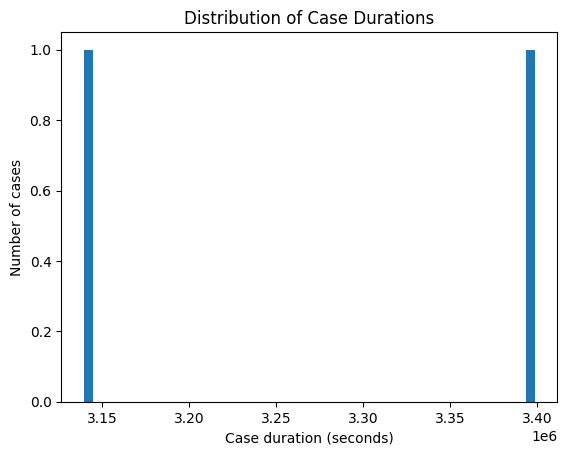

In [15]:
# Plot case duration histogram
import matplotlib.pyplot as plt

plt.hist(case_times['duration_seconds'], bins=50)
plt.xlabel("Case duration (seconds)")
plt.ylabel("Number of cases")
plt.title("Distribution of Case Durations")
plt.show()

## 10. Variants: identifying execution paths

A variant is a unique sequence of activities executed by a case.
Variants are essential for understanding process complexity and deviations.

In [16]:
# Build activity sequences per case
variants = (
    log_df_sorted
    .groupby('case:concept:name')['concept:name']
    .apply(tuple)
)

variants.head()

case:concept:name
201    (Start Shift, End Shift, Start Shift, End Shif...
202    (Start Shift, End Shift, Start Shift, End Shif...
Name: concept:name, dtype: object

In [17]:
# Count variant frequencies
variant_counts = variants.value_counts().reset_index()
variant_counts.columns = ['variant', 'frequency']

variant_counts.head(10)


,variant,frequency
0,"(Start Shift, End Shift, Start Shift, End Shif...",1
1,"(Start Shift, End Shift, Start Shift, End Shif...",1


## 11. Activity frequency analysis

Activity frequencies provide a first structural view of the process.

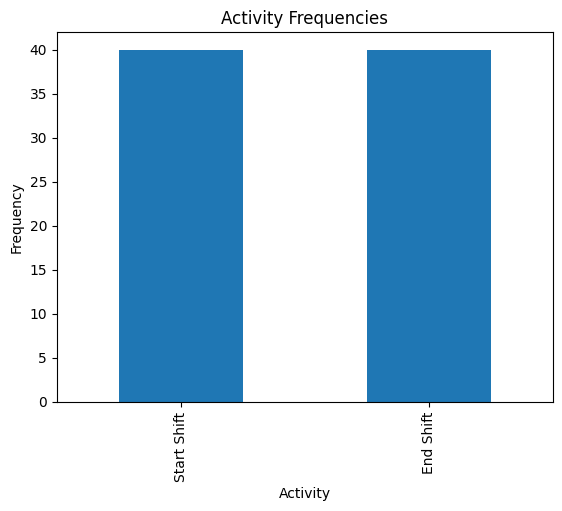

In [18]:
# Bar chart of activity frequencies
activity_counts = log_df['concept:name'].value_counts()

activity_counts.plot(kind='bar')
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.title("Activity Frequencies")
plt.show()


## 12. Temporal analysis: arrivals over time

Event logs often exhibit strong temporal patterns:

- business hours
- daily/weekly seasonality
- batching effects

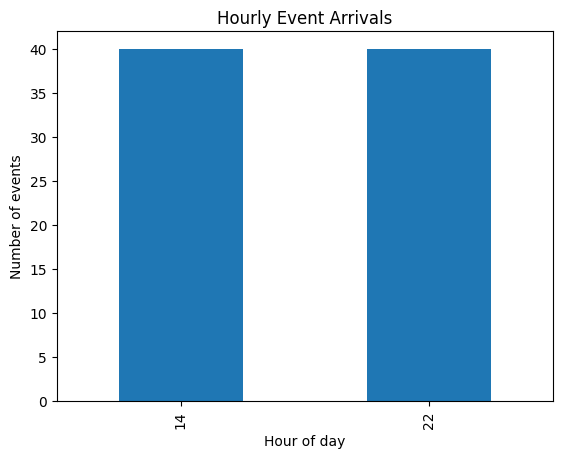

In [19]:
# Hourly arrivals
log_df['hour'] = log_df['time:timestamp'].dt.hour

hourly_arrivals = log_df.groupby('hour').size()

hourly_arrivals.plot(kind='bar')
plt.xlabel("Hour of day")
plt.ylabel("Number of events")
plt.title("Hourly Event Arrivals")
plt.show()

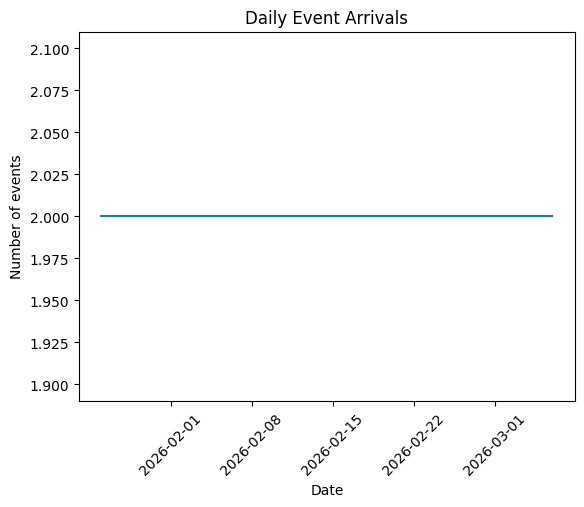

In [20]:
# Daily arrivals
log_df['date'] = log_df['time:timestamp'].dt.date

daily_arrivals = log_df.groupby('date').size()

daily_arrivals.plot()
plt.xticks(rotation=45)
plt.xlabel("Date")
plt.ylabel("Number of events")
plt.title("Daily Event Arrivals")
plt.show()


## 13. Dotted chart (process timeline visualization)

A dotted chart visualizes:

- x-axis → time
- y-axis → cases
- dots → events, colored by activity

This reveals concurrency, batching, and bottlenecks.

In [21]:
import seaborn as sns

In [36]:

start = pd.Timestamp("2026-01-26 00:00:00", tz="UTC")
end   = pd.Timestamp("2026-02-05 23:59:59", tz="UTC")

log_df_day = log_df[
    (log_df['time:timestamp'] >= start) &
    (log_df['time:timestamp'] < end)
]



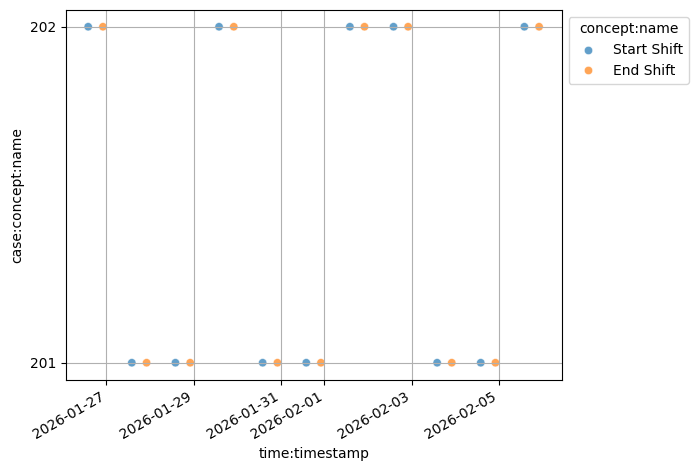

In [37]:
dotted_chart = sns.scatterplot(log_df_day.sort_values(by="time:timestamp"), x='time:timestamp', y='case:concept:name', hue='concept:name', alpha=.7)
sns.move_legend(dotted_chart, "upper left", bbox_to_anchor=(1, 1))
plt.xticks(rotation=30, ha="right")
plt.grid()
dotted_chart;

## 14. Process discovery with pm4py

**Process discovery** automatically derives a process model from event data.
We start with the **Directly-Follows Graph (DFG)** and discover a **Petri net**.

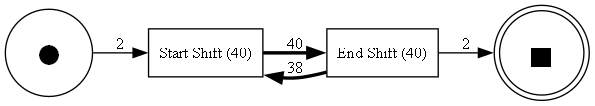

In [24]:
# Discover and visualize DFG
dfg, start_activities, end_activities = pm4py.discover_dfg(log)

pm4py.view_dfg(dfg, start_activities, end_activities)


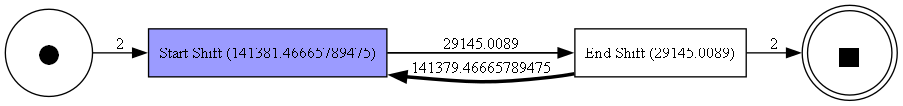

In [25]:
#Performance DFG
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery

# Discover PERFORMANCE DFG (not normal DFG)
dfg_perf = dfg_discovery.apply(log, variant=dfg_discovery.Variants.PERFORMANCE)

# Visualize it
pm4py.view_dfg(dfg_perf, start_activities, end_activities)

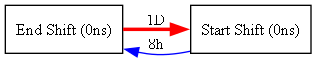

In [38]:
from pm4py.algo.discovery.dfg import algorithm as dfg_discovery
from pm4py.visualization.dfg import visualizer as dfg_vis

# Discover performance DFG
dfg_perf = dfg_discovery.apply(log, variant=dfg_discovery.Variants.PERFORMANCE)

# Visualize in HOURS
gviz = dfg_vis.apply(
    dfg_perf,
    log=log,
    variant=dfg_vis.Variants.PERFORMANCE,
    parameters={"time_unit": "minutes"}
)
dfg_vis.view(gviz)

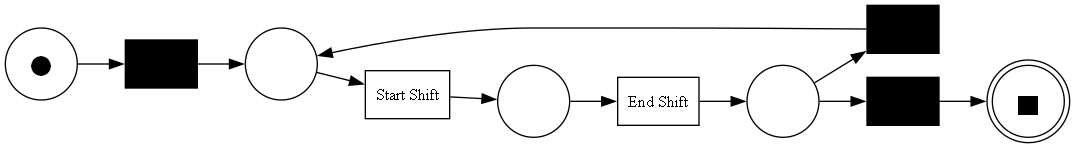

In [27]:
# Discover a Petri net (Inductive Miner)
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(log)

pm4py.view_petri_net(net, initial_marking, final_marking)


## Other things to consider when working with XES logs

- Missing or inconsistent timestamps
- Multiple events with identical timestamps
- Multiple lifecycle events (start / complete)
- Very large logs that do not fit in memory
- Assuming every case follows the same path

Always *inspect before modeling*.
